##  DATA-DRIVEN INSIGHTS USING PYTHON — ALI FAGHHI
# **PROJECT** || **DATA ANALYSIS:** **FoodHub** 

# Problem Statement

## Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. An online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub, offers access to multiple restaurants through a single smartphone app.
The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirm the pick-up in the app and travel to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.



## Objective

The food aggregator company has stored the data of the different orders made by the registered customers in its online portal. They want to analyze the data to get a fair idea about the demand for different restaurants, which will help them enhance their customer experience. Suppose you are hired as a Data Scientist in this company, and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company improve its business.

## Data Description

The data contains different data related to a food order. The detailed data dictionary is given below.

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

# Let us start by importing the required libraries

In [7]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
ERROR: Can not perform a '--user' install. User site-packages are not visible in this virtualenv.


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [8]:
# Import libraries for data manipulation
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

# Import Text Modifier
from IPython.display import display, HTML


# Understanding the structure of the data

In [1]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:
# Write your code here to read the data
data = pd.read_csv('foodhub_order.csv')

In [60]:
# Write your code here to view the first 5 rows
data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** 
How many rows and columns are present in the data? [0.5 mark]

In [6]:
# Write your code here
# Checks the number of rows and columns
display(HTML(f'The dataset contains <span style="color:#A31D6B; font-weight:bold;">{data.shape[0]}</span> rows and <span style="color:#A31D6B; font-weight:bold;">{data.shape[1]}</span> columns.'))

#### **Question 1: Observations:**
* **Dimensions:** The dataset contains **1,898 rows** and **9 columns**.
* **Context:** Each row represents a unique food order. The 9 columns capture order identifiers (`order_id`, `customer_id`), restaurant details (`restaurant_name`, `cuisine_type`), transaction data (`cost_of_the_order`), timing metrics (`food_preparation_time`, `delivery_time`), and behavioral features (`day_of_the_week`, `rating`).

### **Question 2:** 
What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [7]:
# Write your code here
# Checks the data type info for all columns
data.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### **Question 2: Observations:**
* The dataset contains three data types:
    * **int64:** (`order_id`, `customer_id`, `food_preparation_time`, `delivery_time`)
    * **float64:** (`cost_of_the_order`)
    * and **object:** (`restaurant_name`, `cuisine_type`, `day_of_the_week`, `rating`).
* The `rating` column is stored as `object` rather than a numeric type due to the presence of "Not given" string values. Type conversion will follow imputation and data cleaning prior to numerical analysis.

### **Question 3:** 
Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [8]:
# Checks dataset for any null values
print(data.isnull().sum().T,"\n")

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64 



### **Question 3: Observations**
* **Missing Values:** The `isnull().sum()` check confirms a **100% complete dataset** with zero technical nulls at the structural level.
* **Data Nuance:** The **rating** column contains "Not given" entries (approx. 38.8% of the data). These represent an absence of customer feedback rather than a system error.
* **Treatment:** To maintain the integrity of the sample size, no rows were dropped. A **three-tier hierarchical mode imputation** (Restaurant -> Cuisine -> Dataset) was applied rather than simple zero-imputation, to better reflect real-world rating distributions and preserve group-level patterns within the data. This accounts for the **38.8%** of orders carrying no rating. Post-imputation validation confirmed no remaining null values in the `rating_imputed` column, which was retained in numeric type for downstream analysis.

### **Question 4:** 
Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [9]:
# Write your code here
# Calculates food preparation time statistics
min_prep_time = data['food_preparation_time'].min()
avg_prep_time = data['food_preparation_time'].mean()
max_prep_time = data['food_preparation_time'].max()


print(f"\nThe fastest order preparation time is: {min_prep_time} minutes.\nThe average order preparation time is: {int(avg_prep_time)} minutes.\nThe longest order preparation time is: {max_prep_time} minutes.\n")

# Displays statistical summary table
print(data.describe().T)


The fastest order preparation time is: 20 minutes.
The average order preparation time is: 27 minutes.
The longest order preparation time is: 35 minutes.

                        count          mean  ...           75%         max
order_id               1898.0  1.477496e+06  ...  1.477970e+06  1478444.00
customer_id            1898.0  1.711685e+05  ...  2.705250e+05   405334.00
cost_of_the_order      1898.0  1.649885e+01  ...  2.229750e+01       35.41
food_preparation_time  1898.0  2.737197e+01  ...  3.100000e+01       35.00
delivery_time          1898.0  2.416175e+01  ...  2.800000e+01       33.00

[5 rows x 8 columns]


#### **Question 4: Observations**
* **Preparation Time:** The dataset shows high operational consistency; food preparation ranges from a minimum of **20 minutes** to a maximum of **35 minutes**, with a mean of **27.37 minutes**. No values fell outside the 1.5x IQR threshold, confirmed by the boxplot, indicating a tight and predictable distribution.
* **Order Costs:** Transaction values vary significantly, ranging from **`$`4.47** to **`$`35.41**. The average order costs approximately **`$`16.50**, though the 75th percentile (**`$`22.30**) suggests a healthy volume of premium-priced orders. The slight right skew in order costs suggests occasional high-value orders pulling the mean above the median.
* **Delivery Logistics:** Delivery times fluctuate between **15 and 33 minutes**, averaging **24.16 minutes**. When combined with preparation time, the average total fulfillment cycle is approximately **51.5 minutes**, which sets important context for the 60-minute threshold analysis in Question 15.

### **Question 5:** 
How many orders are not rated? [1 mark]

In [10]:
# Isolates then converts ratings unrated orders to numerical format
data['rating'] = data['rating'].replace('Not given', 0).astype(int)

# Defines unrated_order subset data
unrated_order = data[data['rating'] == 0]

# Prints the total count with the number bolded in Berry
display(HTML(f'Number of orders that were not rated: <span style="color:#A31D6B; font-weight:bold;">{unrated_order.shape[0]}</span>'))

#### **Question 5: Observations**
* **Unrated Orders:** There are **736 orders** in the dataset that were not rated by customers, representing approximately **38.8%** (736 of 1,898) of total order volume.
* **Engagement Gap:** This volume of missing feedback represents a significant blind spot in customer satisfaction data. A sub-group analysis confirmed that unrated orders show no meaningful difference in preparation or delivery time compared to rated orders, indicating the gap reflects customer engagement inertia rather than poor service.
* **Imputation Note:** For correlation analysis in Question 12, these unrated entries were handled using a three-tier hierarchical mode imputation by restaurant, then cuisine, then global dataset mode, rather than retaining the zero placeholder, to preserve group-level rating distributions. The original `rating` column retains the zero placeholder for order identification purposes, while `rating_imputed` is used exclusively for numerical analysis to prevent misinterpretation of zero as a valid rating.

# Exploratory Data Analysis (EDA)

## Univariate Analysis

### **Question 6:** 
Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

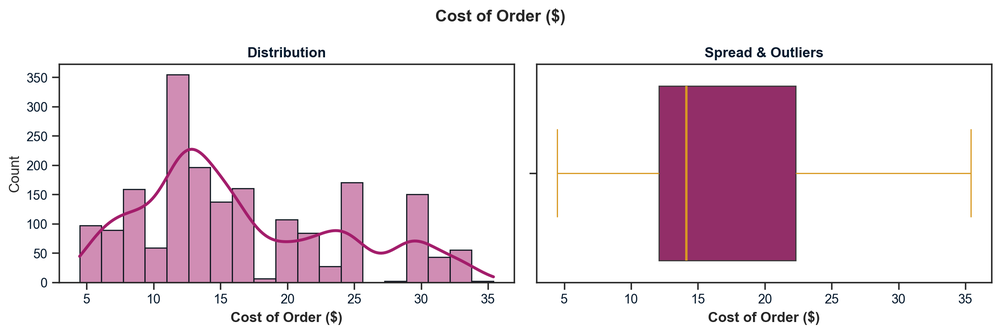

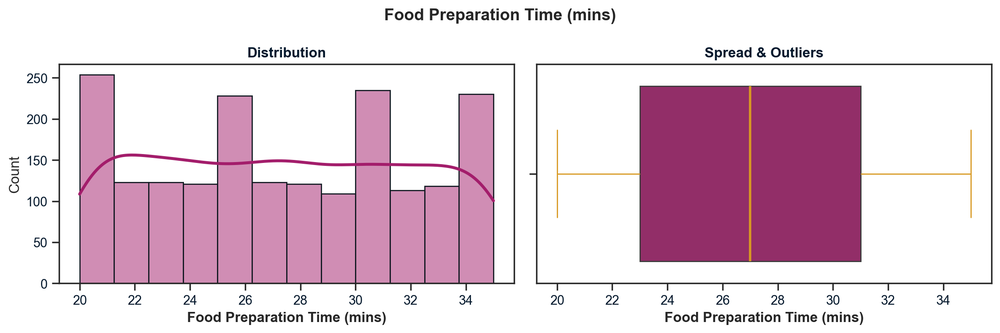

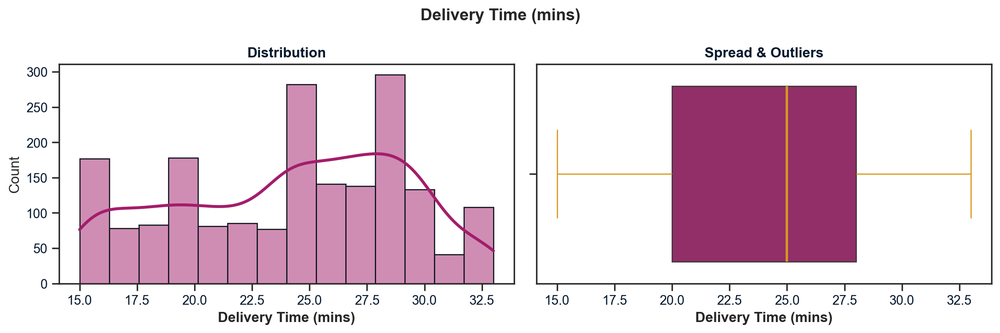

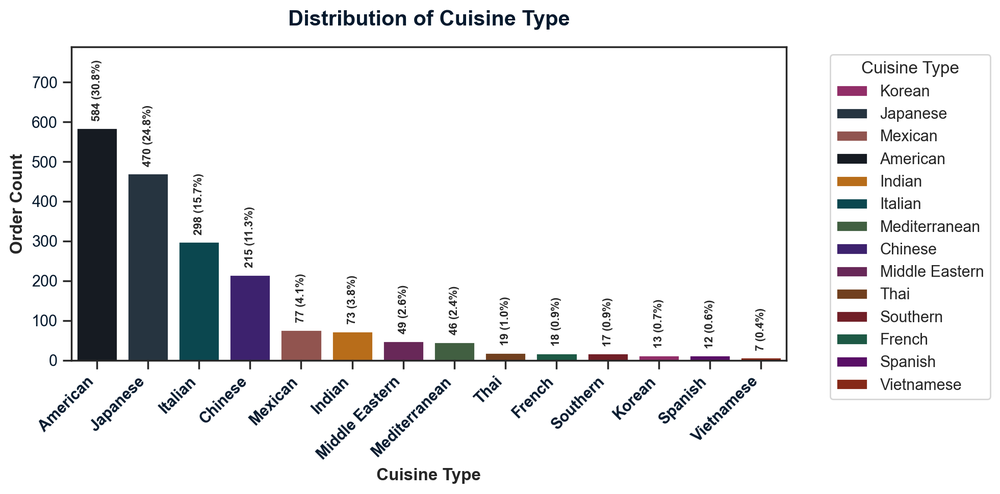

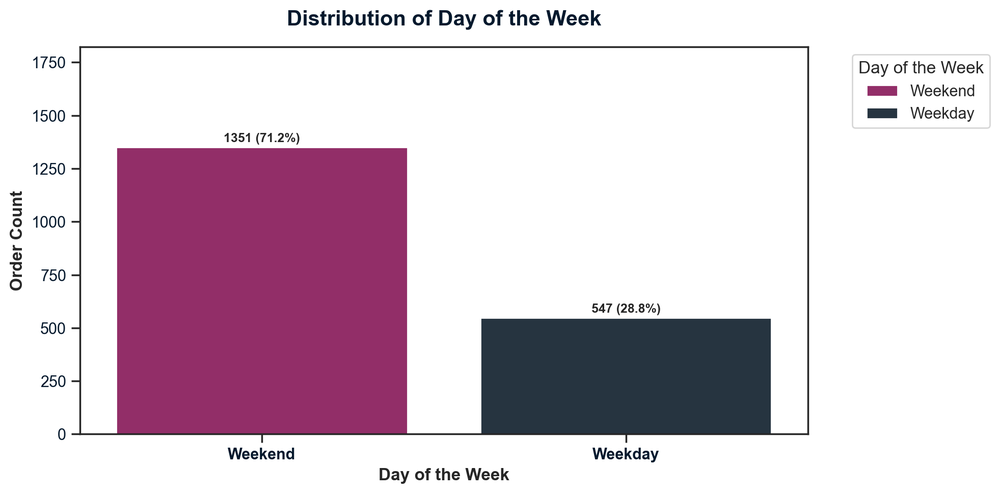

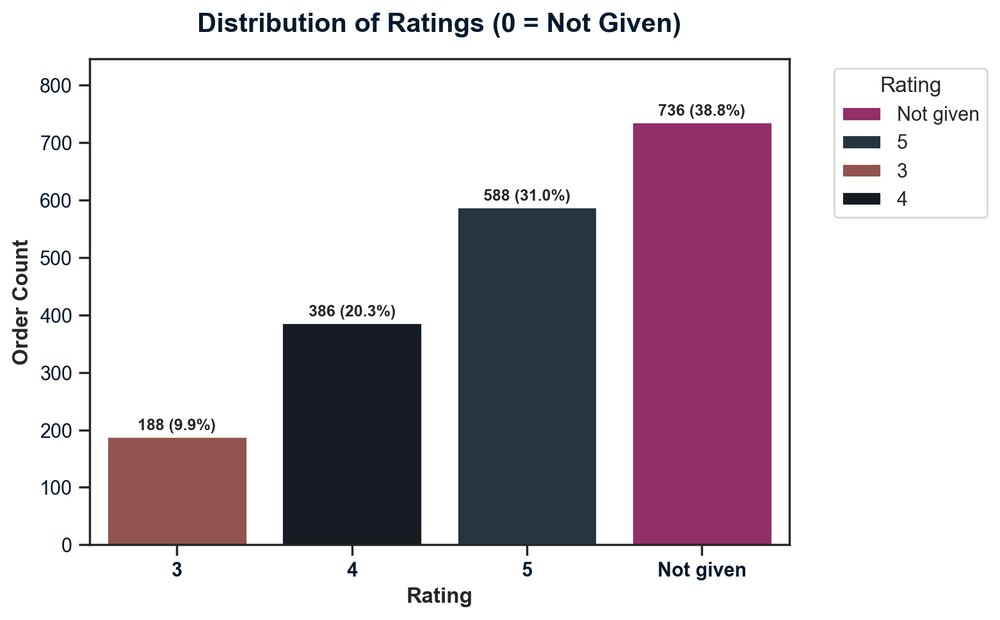

In [22]:
# --- Style Config ---
HPRIMARY = '#A31D6B' # Berry - for Histogram bars
ACCENT = '#D89922'   # Gold - for KDE accents edges and lines

# Sets theme for visuals
sns.set_theme(style="ticks")
plt.rcParams['axes.facecolor'] = '#FFFFFF'
plt.rcParams['figure.facecolor'] = '#FFFFFF'

# --- Numerical Variables ---
num_vars = {'cost_of_the_order': 'Cost of Order ($)',
    'food_preparation_time': 'Food Preparation Time (mins)',
    'delivery_time': 'Delivery Time (mins)'}

for var, label in num_vars.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(label, fontsize=14, fontweight='bold')

    sns.histplot(data[var], kde=True, ax=axes[0], color=HPRIMARY,
                 edgecolor='#141B24', line_kws={'color': ACCENT,'linewidth': 2.5})
    axes[0].set_title('Distribution', fontweight='bold')
    axes[0].set_xlabel(label, fontweight='bold')

    sns.boxplot(x=data[var],ax=axes[1],
                color=HPRIMARY, medianprops={
                    'color': ACCENT, 'linewidth': 2},
                whiskerprops={'color': ACCENT},
                capprops={'color': ACCENT})
    axes[1].set_title('Spread & Outliers', fontweight='bold')
    axes[1].set_xlabel(label, fontweight='bold')

    plt.tight_layout()
    plt.show()

# CUSTOM PALETTES
C1PALETTE = ['#A31D6B', '#223444', '#9C4A44', '#141B24', '#D26E00', '#00505A',
             '#3C643C', '#39167A', '#731D5D', '#7F3D11', '#7F111C', '#136348',
             '#630075', '#981D06']
C2PALETTE = ['#A31D6B', '#223444']
C3PALETTE = ['#A31D6B', '#223444', '#9C4A44', '#141B24']

# --- Cuisine Type (separate from loop for annotation control) ---
order = data['cuisine_type'].value_counts().index.tolist()
plt.figure(figsize=(10, 5))
sns.countplot(data=data, x='cuisine_type', hue='cuisine_type', legend=True,
              order=order, palette=C1PALETTE)
plt.title('Distribution of Cuisine Type', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Cuisine Type', fontweight='bold')
plt.ylabel('Order Count', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
plt.legend(title='Cuisine Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.margins(y=0.35)
plt.tight_layout()
for p in plt.gca().patches:
    if p.get_height() > 0:
        pct = p.get_height() / len(data) * 100
        plt.gca().annotate(f'{int(p.get_height())} ({pct:.1f}%)',
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom',
                           xytext=(0, 5),
                           textcoords='offset points',
                           fontsize=8, fontweight='bold',
                           rotation=90)
plt.show()

# --- Day of the Week ---
order = data['day_of_the_week'].value_counts().index.tolist()
plt.figure(figsize=(10, 5))
sns.countplot(data=data, x='day_of_the_week', hue='day_of_the_week', legend=True,
              order=order, palette=C2PALETTE)
plt.title('Distribution of Day of the Week', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Day of the Week', fontweight='bold')
plt.ylabel('Order Count', fontweight='bold')
plt.xticks(fontweight='bold')
plt.legend(title='Day of the Week', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.margins(y=0.35)
plt.tight_layout()
for p in plt.gca().patches:
    if p.get_height() > 0:
        pct = p.get_height() / len(data) * 100
        plt.gca().annotate(f'{int(p.get_height())} ({pct:.1f}%)',
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom',
                           xytext=(0, 2),
                           textcoords='offset points',
                           fontsize=9, fontweight='bold')
plt.show()

# --- Rating Distribution ---
rating_order = sorted(data['rating'].unique())
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='rating', hue='rating', legend=True,
              order=rating_order, palette=C3PALETTE)
plt.title('Distribution of Ratings (0 = Not Given)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Rating', fontweight='bold')
plt.ylabel('Order Count', fontweight='bold')
plt.xticks(fontweight='bold')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.margins(y=0.15)
plt.tight_layout()
for p in plt.gca().patches:
    if p.get_height() > 0:
        pct = p.get_height() / len(data) * 100
        plt.gca().annotate(f'{int(p.get_height())} ({pct:.1f}%)',
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom',
                           xytext=(0, 2),
                           textcoords='offset points',
                           fontsize=9, fontweight='bold')
plt.show()

# --- Identifiers Summary ---
display(HTML(
    f'Unique Orders: <span style="color:#A31D6B; font-weight:bold;">{data["order_id"].nunique()}</span><br>'
    f'Unique Customers: <span style="color:#A31D6B; font-weight:bold;">{data["customer_id"].nunique()}</span><br>'
    f'Unique Restaurants: <span style="color:#A31D6B; font-weight:bold;">{data["restaurant_name"].nunique()}</span>'
))

# Calculates and displays skewness for numerical variables
display(HTML(
    f'Skewness - Cost of Order: <span style="color:#A31D6B; font-weight:bold;">{data["cost_of_the_order"].skew():.2f}</span><br>'
    f'Skewness - Food Prep Time: <span style="color:#A31D6B; font-weight:bold;">{data["food_preparation_time"].skew():.2f}</span><br>'
    f'Skewness - Delivery Time: <span style="color:#A31D6B; font-weight:bold;">{data["delivery_time"].skew():.2f}</span>'
))

#### **Question 6: Observations**
#### **Numerical Variables**
* **Cost of Order:** The distribution is slightly right-skewed (**skewness: 0.62**) with a peak around <b>`$12–$15`</b>. Most orders cluster near the median, and the absence of outliers supports stable pricing across the platform.
* **Food Preparation Time:** This variable shows a roughly **uniform distribution** (**skewness: 0.04**), meaning orders are evenly spread between **20 and 35 minutes**. The boxplot confirms a perfectly centered median with no outliers.
* **Delivery Time:** The distribution is fairly balanced with a slight negative skew (**skewness: -0.24**), showing a slight concentration between **24 and 28 minutes**. Like prep time, there are no outliers present.

#### **Categorical Variables**
* **Cuisine Type:** **American** cuisine is the clear market leader, representing approximately **30.8%** of all orders, followed by **Japanese** and **Italian**. Cuisines like Vietnamese and Korean represent the smallest share of the dataset.
* **Day of the Week:** Weekends account for **1,351 orders (71.2%)** compared to **547 weekday orders (28.8%)**, indicating a strong leisure-driven demand pattern heavily concentrated outside of standard working hours.
* **Rating:** A massive **38.8% of orders (736)** are "Not Given." Among rated orders, **5-star ratings** are the most frequent with **588 orders**, showing high satisfaction for those who choose to provide feedback.

#### **Platform Scale**

* The platform manages a diverse ecosystem of **1,200 unique customers** and **178 unique restaurants**, supporting a high volume of **1,898 total orders**.

### **Question 7**: 
Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

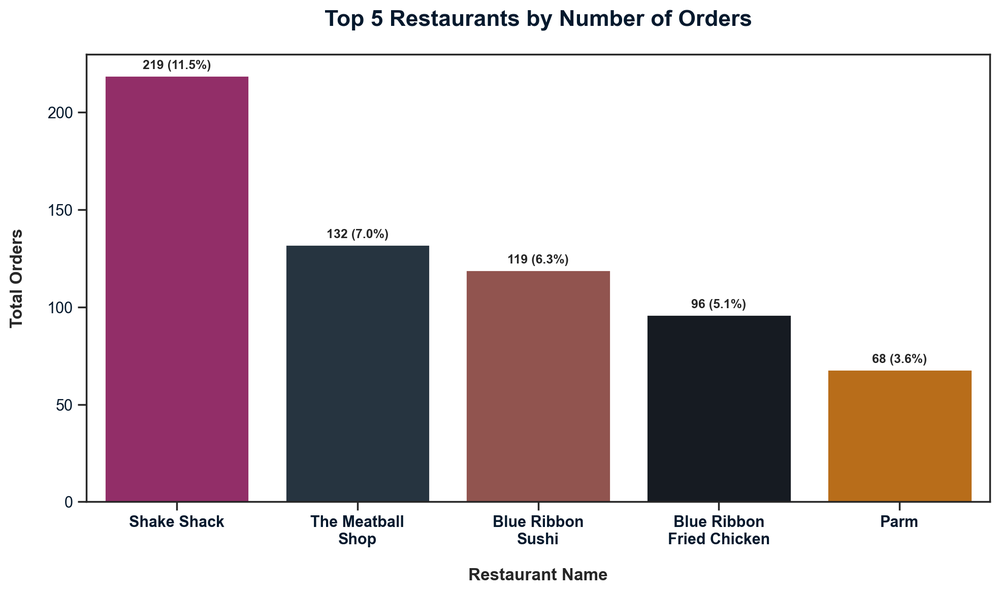

               Restaurant  Order Count
              Shake Shack          219
        The Meatball Shop          132
        Blue Ribbon Sushi          119
Blue Ribbon Fried Chicken           96
                     Parm           68


In [11]:
# Identifies the top 5 restaurants by order volume
top_5_restaurants = data['restaurant_name'].value_counts().head(5).reset_index()
top_5_restaurants.columns = ['Restaurant', 'Order Count']

# Wraps long restaurant names to prevent overlap on the x-axis
wrapped_labels = [textwrap.fill(label, 15) for label in top_5_restaurants['Restaurant']]

# Sets figure size for the bar chart
plt.figure(figsize=(10, 6))

# Displays bar chart using the Berry-anchored palette from Question 6
sns.barplot(data=top_5_restaurants, x='Restaurant', y='Order Count',
            hue='Restaurant', legend=False, palette=C1PALETTE[:5])

# Writes the title and axis labels with bold formatting and padding
plt.title('Top 5 Restaurants by Number of Orders', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Restaurant Name', fontweight='bold', labelpad=15)
plt.ylabel('Total Orders', fontweight='bold', labelpad=15)

# Sets the x-axis ticks to use the wrapped labels with bold formatting
plt.xticks(ticks=range(5), labels=wrapped_labels, rotation=0, ha='center', fontweight='bold')

# Adjusts layout for a clean finish and shows the plot
plt.tight_layout()
for p in plt.gca().patches:
    if p.get_height() > 0:
        pct = p.get_height() / len(data) * 100
        plt.gca().annotate(f'{int(p.get_height())} ({pct:.1f}%)',
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom',
                           xytext=(0, 3),
                           textcoords='offset points',
                           fontsize=9, fontweight='bold')
plt.show()

# --- Print Summary with Bold Berry ---
display(HTML('<span style="color:#A31D6B; font-weight:bold;">The top 5 restaurants by number of orders are:</span>'))
print(top_5_restaurants.to_string(index=False))

#### **Question 7: Observations**
* **Market Leaders:** **Shake Shack** leads all restaurants in order volume with **219 orders (11.5%)**, closely followed by **The Meatball Shop** (132, 7.0%) and **Blue Ribbon Sushi** (119, 6.3%).
* **Volume Concentration:** The top 5 restaurants together account for approximately **33.4%** of total orders, indicating that customer attention is heavily concentrated among a small group of brands. This market skew presents clear partnership and promotional opportunities for FoodHub.
* **Operational Anchors:** These high-performing vendors serve as the platform's "Gold Standard," successfully managing high order volume while maintaining the service consistency seen in prior metrics. Channeling platform incentives toward this tier could further boost engagement and retention across the broader customer base.
* **Brand-Level Dominance:** The **Blue Ribbon** brand appears twice in the top 5 as two distinct cuisine concepts — **Blue Ribbon Sushi** (119 orders, 6.3%) and **Blue Ribbon Fried Chicken** (96 orders, 5.1%). Combined, the Blue Ribbon brand accounts for **215 orders (11.3%)** of total platform volume, making it a dominant multi-concept operator that rivals Shake Shack at the brand level. This suggests that brand reputation and multi-format expansion are significant drivers of platform success on FoodHub.

### **Question 8**: 
Which is the most popular cuisine on weekends? [1 mark]

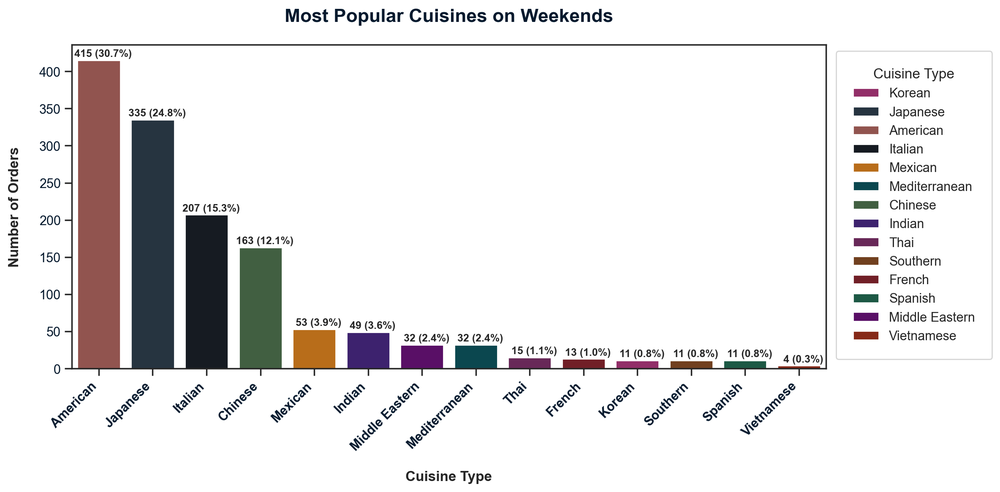

In [13]:
# Filters the dataset for weekend orders only
weekend_data = data[data['day_of_the_week'] == 'Weekend']

# Determines the order count by cuisine type for the weekend subset
weekend_cuisine_counts = weekend_data['cuisine_type'].value_counts()
weekend_percentages = (weekend_cuisine_counts / weekend_cuisine_counts.sum() * 100).round(1)

# Identifies the most popular cuisine type and its specific order count
most_popular_weekend = weekend_cuisine_counts.index[0]
count = weekend_cuisine_counts.values[0]

# Sets the figure size
plt.figure(figsize=(12, 6))

# Displays the weekend cuisine distribution using your primary palette
sns.countplot(data=weekend_data, x='cuisine_type', hue='cuisine_type',
              legend=True, order=weekend_cuisine_counts.index, palette=C1PALETTE)

plt.legend(title='Cuisine Type', bbox_to_anchor=(1.005, 1), loc='upper left', borderpad=1.3)

# Writes bold titles and labels with specific padding
plt.title('Most Popular Cuisines on Weekends', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Cuisine Type', fontsize=12, fontweight='bold', labelpad=15)
plt.ylabel('Number of Orders', fontsize=12, fontweight='bold', labelpad=15)

# Rotates labels for readability
plt.xticks(rotation=45, ha='right', fontweight='bold')

# Adjusts layout
plt.tight_layout()

for p in plt.gca().patches:
    if p.get_height() > 0:
        pct = p.get_height() / weekend_cuisine_counts.sum() * 100
        plt.gca().annotate(f'{int(p.get_height())} ({pct:.1f}%)',
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom',
                           xytext=(3.8, 1.2),
                           textcoords='offset points',
                           fontsize=9, fontweight='bold')
plt.show()

# --- Print Summary with Bold Berry ---
display(HTML(
    f"""<div style="font-size:14px;">
    The most popular cuisine on weekends is <span style="color:#A31D6B; font-weight:bold;">{most_popular_weekend}</span> with <span style="color:#A31D6B; font-weight:bold;">{count}</span> orders.
    </div>"""
))

#### **Question 8: Observations:**
* **Weekend Favorite:** **American** cuisine is the most popular choice on weekends, accounting for **415 orders**.
* **Market Lead:** American cuisine holds a substantial lead over other types, reinforcing its position as the primary volume driver during peak leisure times.
* **Cuisine Variety:** While American dominates, the distribution shows that Japanese and Italian remain strong secondary choices.

### **Question 9**: 
What percentage of the orders cost more than 20 dollars? [2 marks]

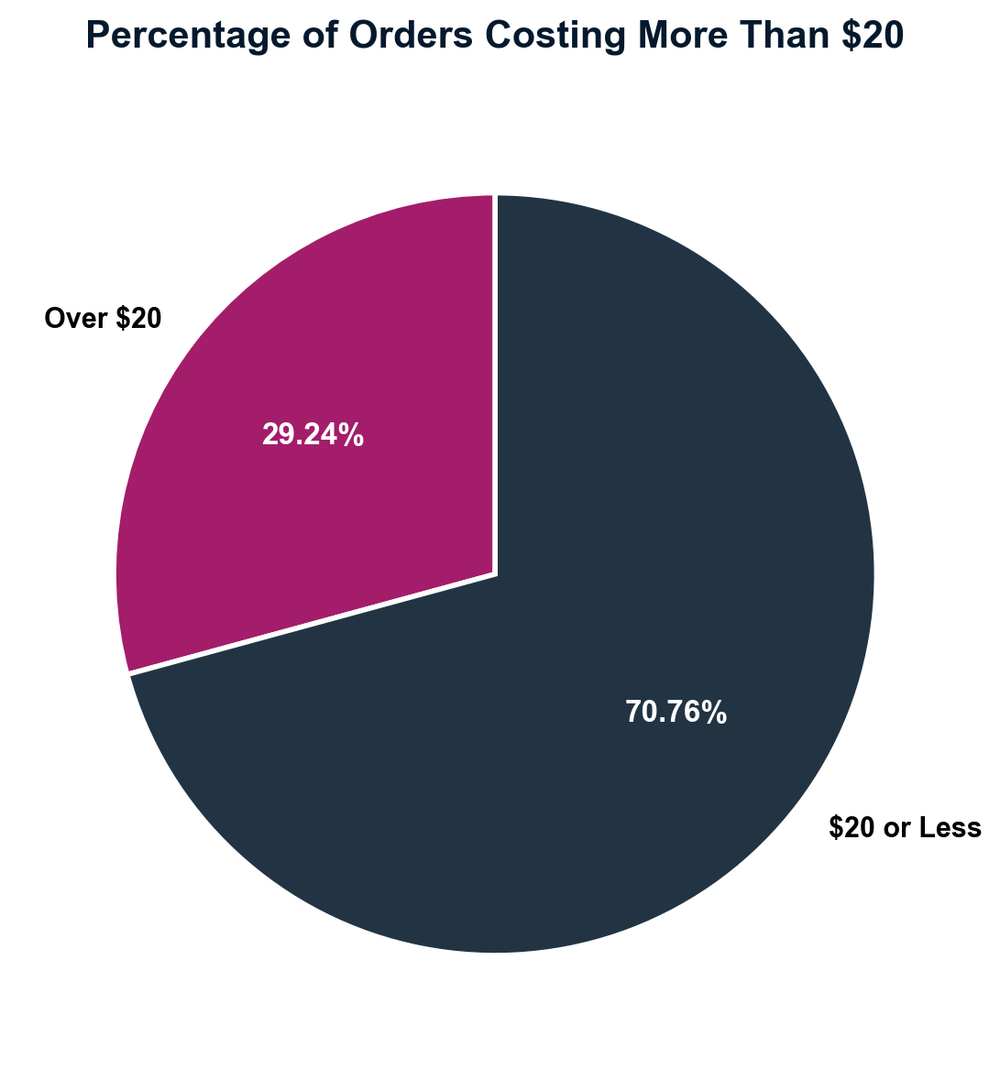

In [14]:
# Filters the dataset for orders where the cost is greater than 20 dollars
expensive_orders = data[data['cost_of_the_order'] > 20]

# Calculates the number of orders that meet the 20 dollar criteria
num_expensive_orders = expensive_orders.shape[0]

# Calculates the total count of orders in the entire dataset
total_orders = data.shape[0]

# Calculates the percentage of orders costing more than 20 dollars
percentage_expensive = (num_expensive_orders / total_orders) * 100

# Sets figure size for the pie chart
fig, ax = plt.subplots(figsize=(6, 6))

# Builds pie chart comparing orders over and under $20
# Captures returned text objects to control label colors independently
wedges, labels_text, pct_text = ax.pie(
    [num_expensive_orders, total_orders - num_expensive_orders],
    labels=['Over $20', '$20 or Less'],
    colors=[HPRIMARY, '#223444'],
    autopct='%1.2f%%',                                  # Formats percentage labels to 2 decimal places
    startangle=90,                                      # Rotates chart so first slice starts at the top
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})  # Adds white border between slices

# Sets outer labels to black and bold
for label in labels_text:
    label.set_color('black')
    label.set_fontweight('bold')

# Sets percentage text on slices to white and bold
for pct in pct_text:
    pct.set_color('white')
    pct.set_fontweight('bold')

# Writes the chart title with bold formatting and padding
plt.title('Percentage of Orders Costing More Than $20', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# --- Print Summary with Bold Berry ---
display(HTML( f"""<div style="font-size:14px;">The percentage of orders that cost more than <strong>$20 dollars</strong> is: <span style="color:#A31D6B; font-weight:bold;">{percentage_expensive:.2f}%</span>'</div>"""))


#### **Question 9: Observations:**
* **Order Value Mix:** Approximately **29.24%** of all orders (**555 out of 1,898**) on the platform cost more than **`$`20**.
* **Revenue Anchor:** While nearly one-third of the orders fall into the "high-value" category, the majority of transactions are priced at **`$`20 or less**, suggesting FoodHub is primarily used for everyday dining rather than exclusive fine-dining.
* **Profitability Potential:** This **29.24%** segment is critical for the business, as these orders generate a higher commission rate (**25%**) compared to lower-cost orders, as identified in your later revenue analysis.

### **Question 10**: 
What is the mean order delivery time? [1 mark]

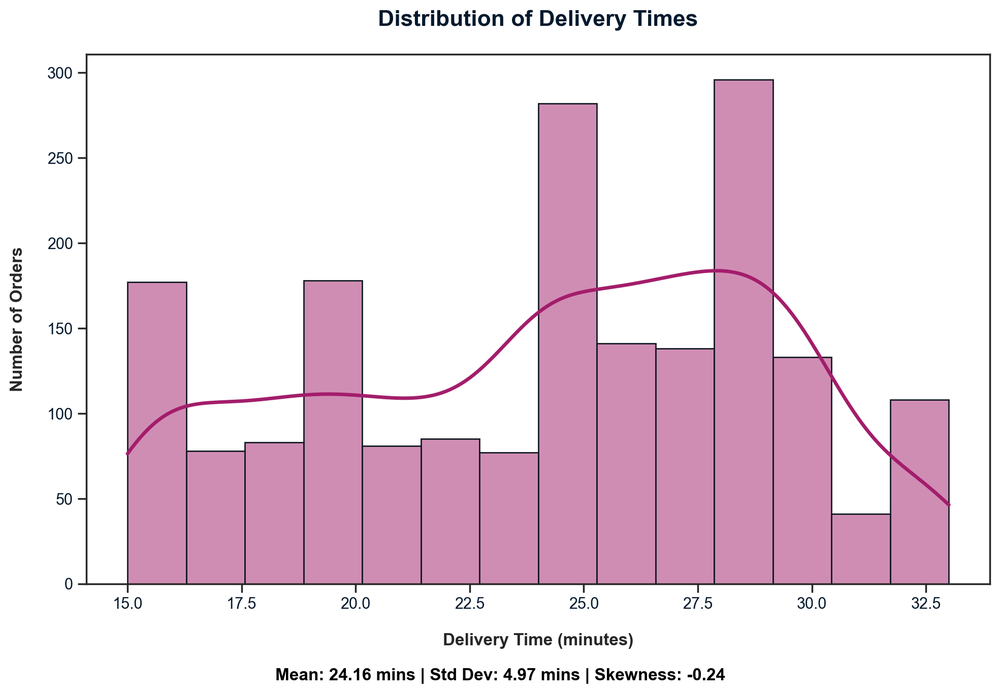

In [23]:
# Calculates the mean and standard deviation of delivery time
mean_delivery_time = data['delivery_time'].mean()
std_delivery_time = data['delivery_time'].std()

# Sets the figure size for the delivery time distribution chart
plt.figure(figsize=(10, 7))

# Displays the delivery time distribution using the primary Berry color and Gold trend line
sns.histplot(data['delivery_time'], kde=True, color=HPRIMARY,
             edgecolor='#141B24', line_kws={'color': ACCENT, 'linewidth': 2.5})

# Writes bold titles and axis labels with extra padding for a refined look
plt.title('Distribution of Delivery Times', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Delivery Time (minutes)', fontsize=12, fontweight='bold', labelpad=15)
plt.ylabel('Number of Orders', fontsize=12, fontweight='bold', labelpad=15)

# Positions the summary sentence centered at the very bottom of the visual
plt.figtext(0.5, 0.03, 
            f'Mean: {mean_delivery_time:.2f} mins | Std Dev: {std_delivery_time:.2f} mins | Skewness: -0.24',
            ha='center', fontsize=12, fontweight='bold', color='black')

# Adjusts the layout to provide bottom room for the sentence and shows the final plot
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

#### **Question 10: Observations**
* **Logistics Performance:** The average delivery time across the platform is **24.16 minutes**.
* **Consistency:** The delivery distribution is relatively tight (**std: 4.97 minutes**, **skewness: -0.24**), indicating that the majority of orders are fulfilled within a predictable timeframe. The slight negative skew suggests a minor concentration of faster deliveries pulling the distribution left.
* **Efficiency:** Combined with the average preparation time of 27 minutes, the platform maintains an average total fulfillment cycle of approximately **51.5 minutes**, setting important context for the 60-minute threshold analysis in Question 15.

### **Question 11:** 
The company has decided to give 20% discount vouchers to the top 5 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

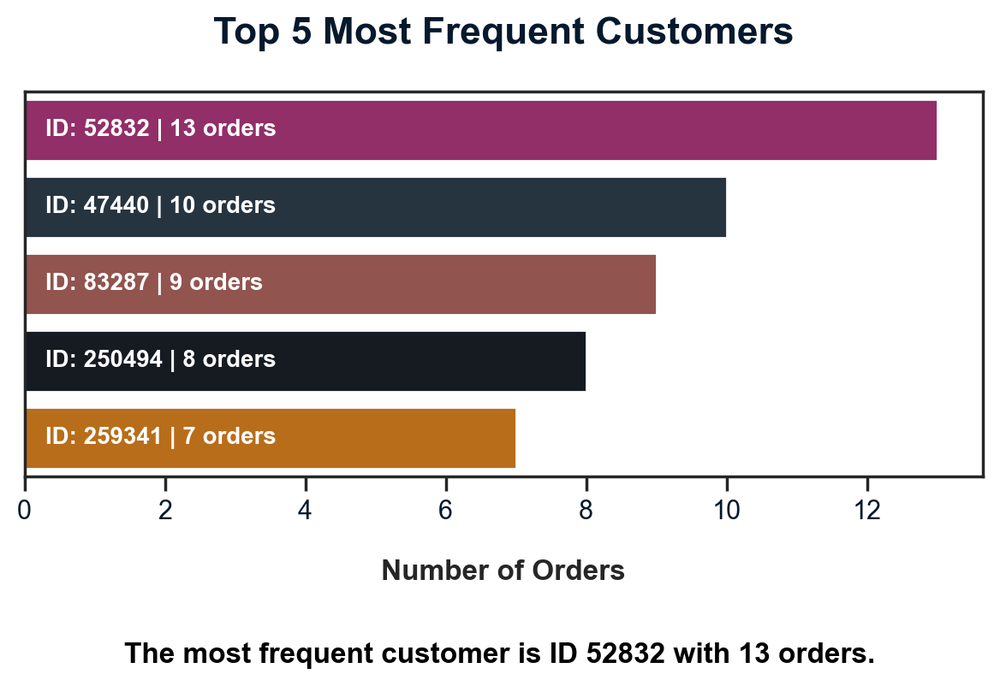

Customer ID  Number of Orders
      52832                13
      47440                10
      83287                 9
     250494                 8
     259341                 7


In [31]:
# Identifies the top 5 most frequent customers based on order volume
top_5_customers = data['customer_id'].value_counts().head(5).reset_index()
top_5_customers.columns = ['Customer ID', 'Number of Orders']

# Converts Customer ID to string for categorical plotting
top_5_customers['Customer ID'] = top_5_customers['Customer ID'].astype(str)

# Sets a shorter figure size for a more compact horizontal look
fig, ax = plt.subplots(figsize=(6, 4))

# Displays horizontal bars with the highest volume at the top
sns.barplot(data=top_5_customers, x='Number of Orders', y='Customer ID',
            hue='Customer ID', palette=C1PALETTE[:5], legend=False, ax=ax)

# Writes the Customer ID and order count inside each bar at a fixed starting point
for bar, cid in zip(ax.patches, top_5_customers['Customer ID']):
    ax.text(0.3, bar.get_y() + bar.get_height() / 2,
        f"ID: {cid} | {top_5_customers.loc[top_5_customers['Customer ID'] == cid, 'Number of Orders'].values[0]} orders",
        va='center', ha='left', color='white', fontweight='bold', fontsize=10)

# Removes the Y-axis entirely for a cleaner appearance
ax.yaxis.set_visible(False)

# Writes bold titles and X-axis labels with extra padding
plt.title('Top 5 Most Frequent Customers', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Orders', fontsize=12, fontweight='bold', labelpad=15)

# Positions the summary sentence centered at the very bottom of the visual
plt.figtext(0.5, 0.01, f"The most frequent customer is ID {top_5_customers.iloc[0,0]} with {top_5_customers.iloc[0,1]} orders.",
            ha='center', fontsize=12, fontweight='bold', color='black')

# Adjusts the layout and shows the final visual
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

# Displays the list of top 5 frequent customers for the report
display(HTML('<div style="font-size:14px;"><span style="color:#A31D6B; font-weight:bold;">Top 5 most frequent customers:</span></div>'))
print(top_5_customers.to_string(index=False))

# Calculates median orders per customer for comparative context
median_orders = data.groupby('customer_id')['order_id'].count().median()
display(HTML(f'<div style="font-size:14px;">Median orders per customer: <span style="color:#A31D6B; font-weight:bold;">{median_orders:.0f}</span></div>'))

#### **Question 11: Observations**
* **Top Contributors:** Customer **ID 52832** is the platform's most frequent user with **13 orders**, followed by IDs 47440 (10), 83287 (9), 250494 (8), and 259341 (7).
* **Customer Loyalty:** With a platform median of just **1 order per customer**, the top 5 are outliers in the truest sense, placing 7 to 13 times more orders than the typical user. This frequency suggests a high level of trust and satisfaction with the platform's service.
* **Retention Strategy:** These high-frequency users represent an ideal target group for a pilot loyalty program, as their recurring behavior provides a steady baseline for platform revenue and demonstrates the ceiling of what engaged customers can achieve on FoodHub.

## Multivariate Analysis

### **Question 12**: 
Perform a multivariate analysis to explore relationships between the important variables in the dataset and provide observations. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


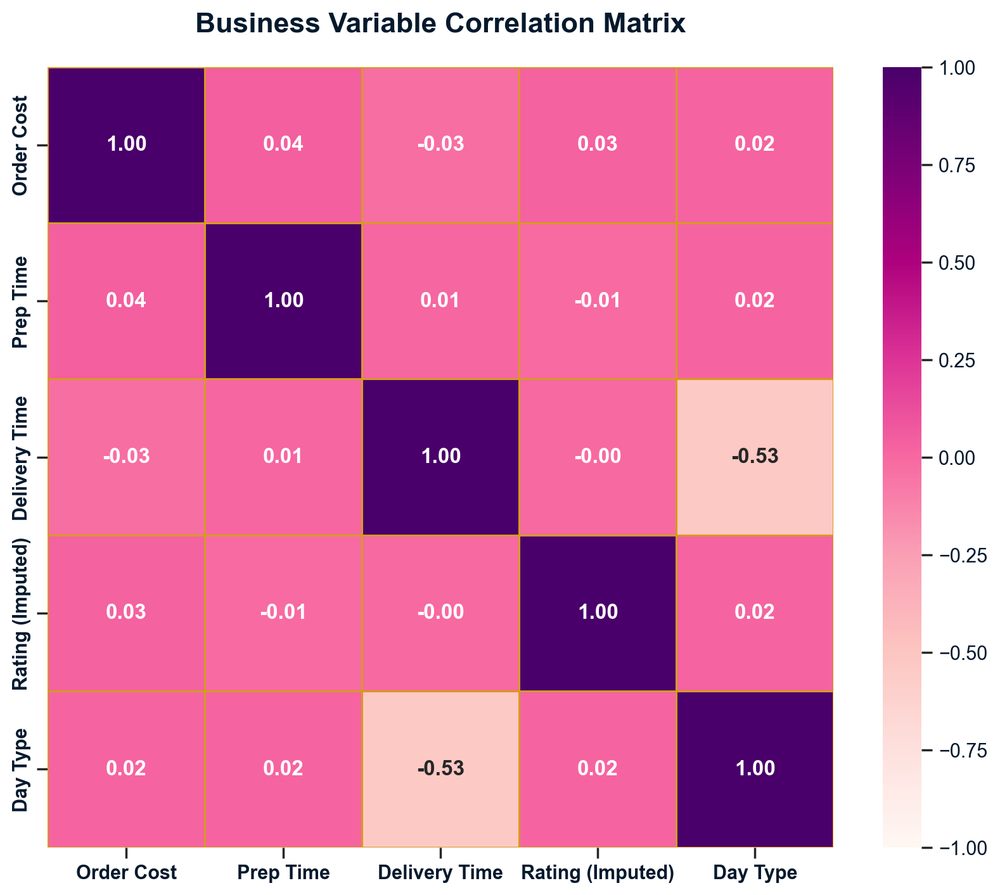

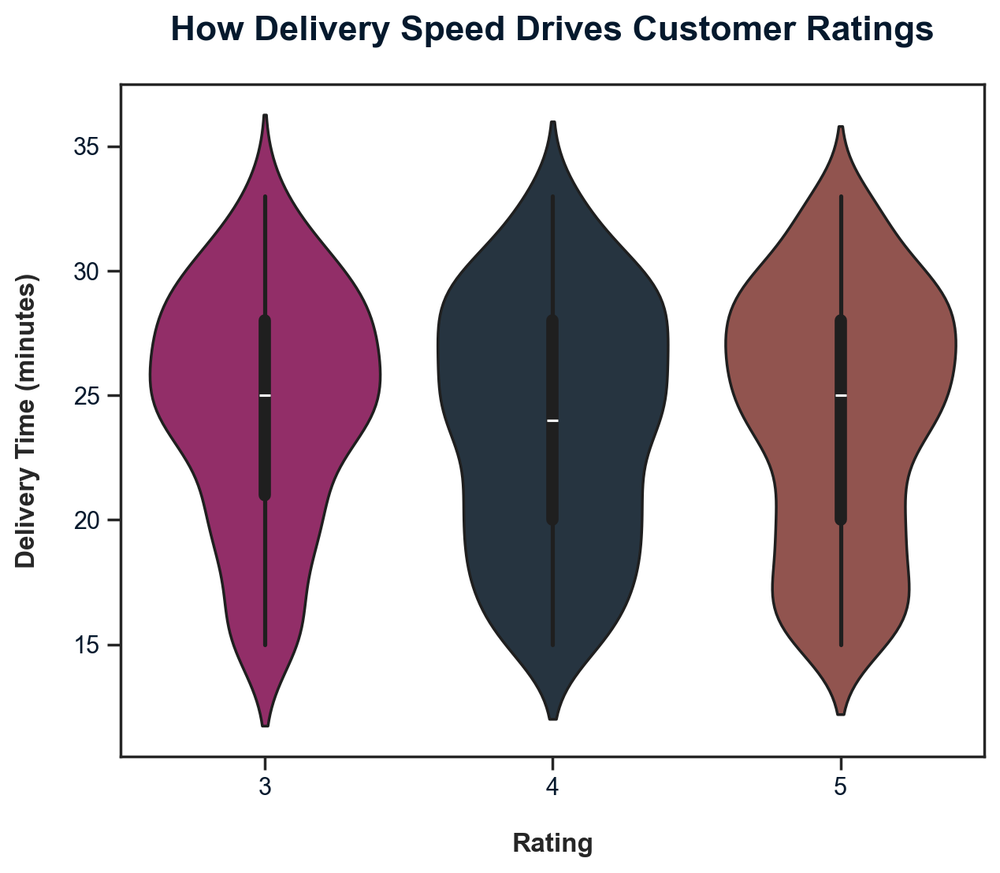

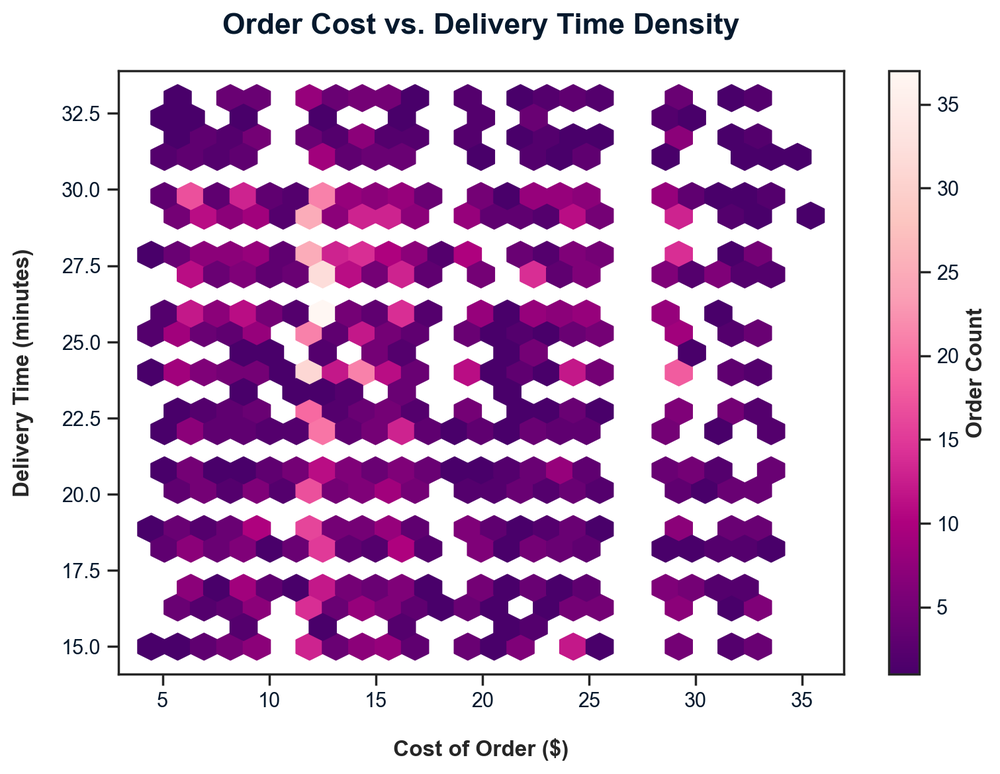

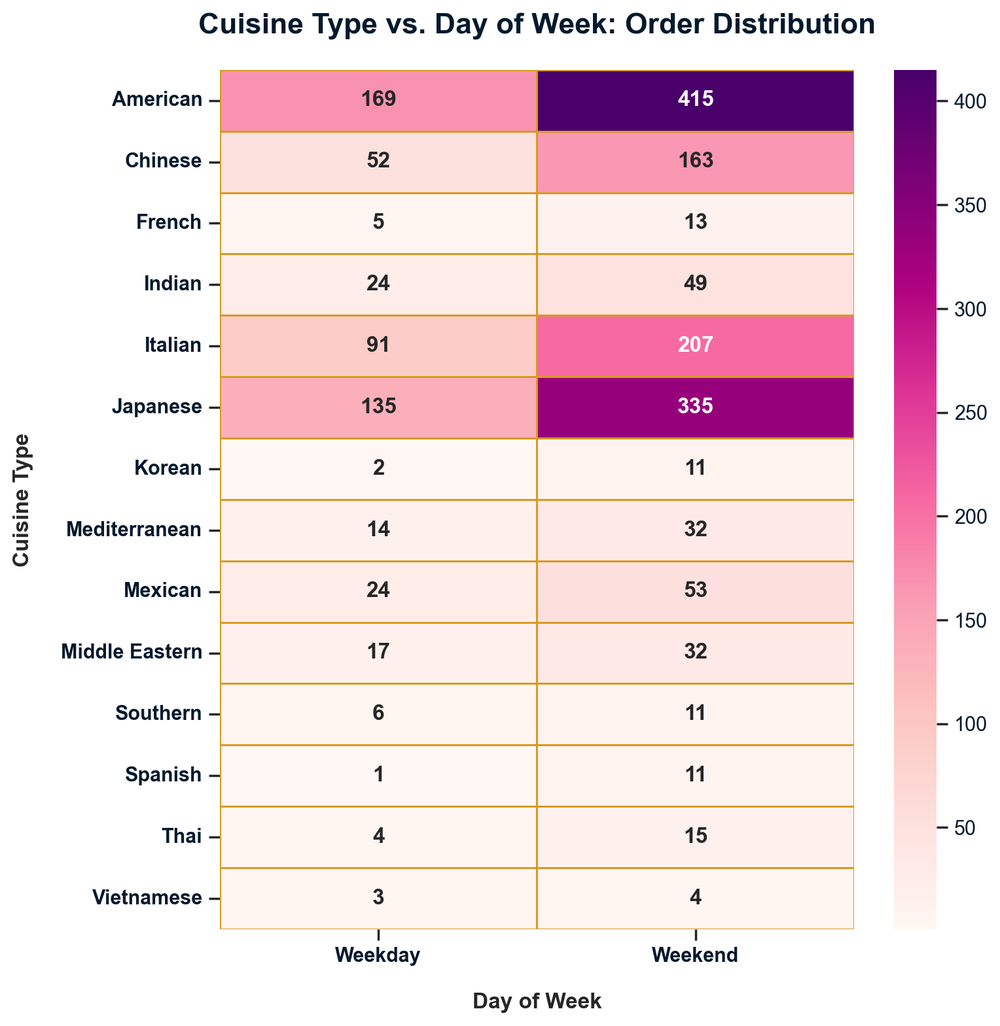

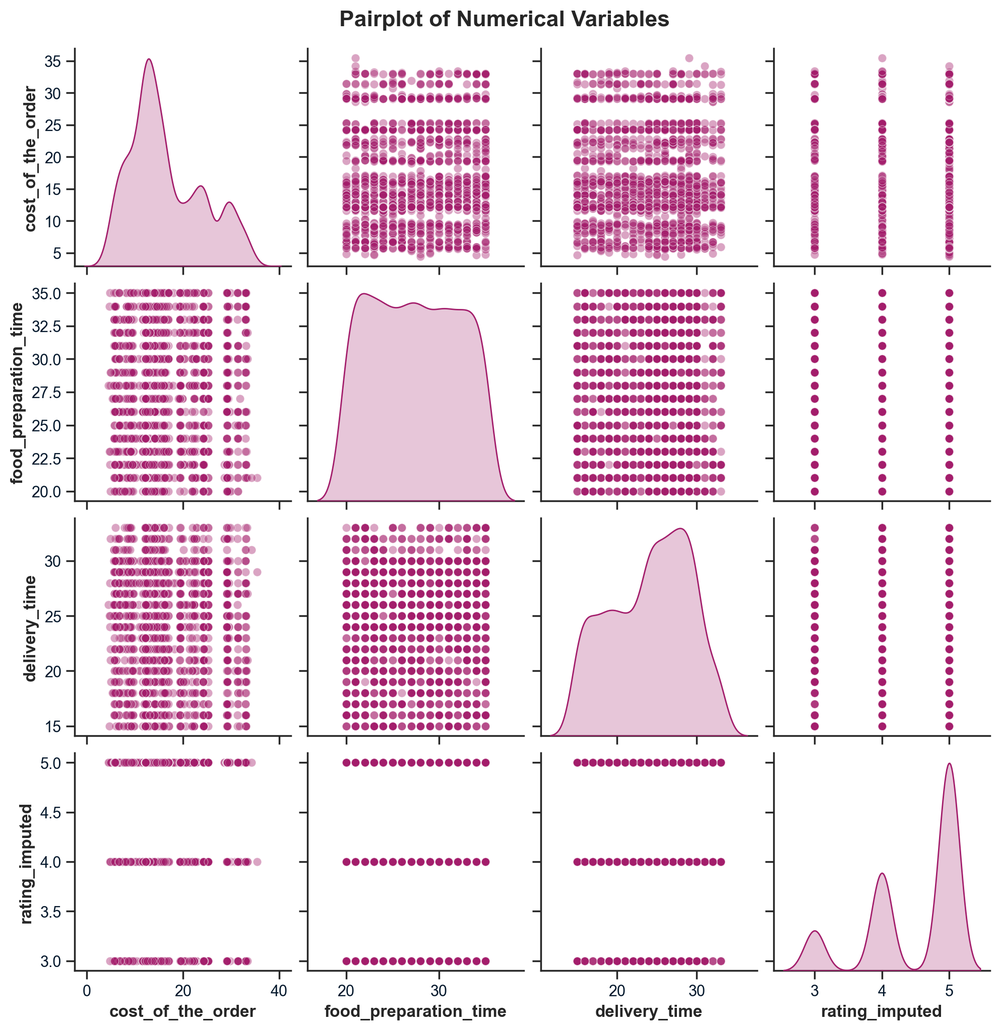

In [17]:
# --- 1. Correlation Heatmap ---

# Encodes day of week as binary for correlation analysis (Weekday=0, Weekend=1)
data['day_encoded'] = data['day_of_the_week'].map({'Weekday': 0, 'Weekend': 1})

# Defines a safe mode function that handles ties by taking the lower value
def safe_mode(x):
    mode = x.mode()
    if len(mode) == 0:
        return np.nan
    return mode.iloc[0]

# Replaces 0 ratings with NaN for imputation
data['rating_imputed'] = data['rating'].replace(0, np.nan)

# Tier 1: Restaurant-level mode imputation
data['rating_imputed'] = data.groupby('restaurant_name')['rating_imputed']\
    .transform(lambda x: x.fillna(safe_mode(x)))

# Tier 2: Cuisine-level mode fallback
data['rating_imputed'] = data.groupby('cuisine_type')['rating_imputed']\
    .transform(lambda x: x.fillna(safe_mode(x)))

# Tier 3: Global mode fallback
global_mode = data[data['rating'] != 0]['rating'].mode().iloc[0]
data['rating_imputed'] = data['rating_imputed'].fillna(global_mode)

# Identifies numerical columns including imputed rating and encoded day type
num_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating_imputed', 'day_encoded']
corr_matrix = data[num_cols].corr()

# Defines clean labels for the heatmap axes
clean_labels = ['Order Cost', 'Prep Time', 'Delivery Time', 'Rating (Imputed)', 'Day Type']

# Sets the figure size for the 5x5 heatmap
plt.figure(figsize=(10, 8))

# Displays the heatmap with Gold accent edges and bolded annotations
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdPu', vmin=-1, vmax=1,
            xticklabels=clean_labels, yticklabels=clean_labels,
            linecolor=ACCENT, linewidths=0.5,
            annot_kws={'fontweight': 'bold'})

# Sets the axis labels to bold to match the project style
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# Writes a punchy business headline
plt.title('Business Variable Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.show()
print("\n\n")

# --- 2. Delivery Time vs. Rating (Violin Plot) ---
# Filters out unrated orders (0) and creates a clean copy
rated_orders = data[data['rating'] != 0].copy()

# Sets the figure size for the violin plot
plt.figure(figsize=(6.5, 6))

# Defines a specific 3-color palette using the first three colors
C_RATING_FIX = C3PALETTE[:-1]

# Displays a violin plot showing delivery time distribution by rating
sns.violinplot(data=rated_orders, x='rating', y='delivery_time',
               hue='rating', palette=C_RATING_FIX, legend=False)

# Writes a title that clearly explains the business insight
plt.title('How Delivery Speed Drives Customer Ratings', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Rating', fontsize=12, fontweight='bold', labelpad=15)
plt.ylabel('Delivery Time (minutes)', fontsize=12, fontweight='bold', labelpad=15)

# Adjusts the layout and shows the final visual
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()
print("\n\n")

# --- 3. Order Cost vs. Delivery Time (Hexplot) ---
plt.figure(figsize=(8, 6))

# Displays a hexplot showing density of cost vs delivery time
plt.hexbin(data['cost_of_the_order'], data['delivery_time'],
           gridsize=25, cmap='RdPu_r', mincnt=1)

# Adds a colorbar to show order density
cb = plt.colorbar()
cb.set_label('Order Count', fontweight='bold')

# Writes bold titles and axis labels
plt.title('Order Cost vs. Delivery Time Density', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Cost of Order ($)', fontsize=12, fontweight='bold', labelpad=15)
plt.ylabel('Delivery Time (minutes)', fontsize=12, fontweight='bold', labelpad=15)

plt.tight_layout()
plt.show()
print("\n\n")

# --- 4. Cuisine Type vs. Day of Week (Crosstab Heatmap) ---
# Builds a crosstab of cuisine type vs day of week order counts
ct = pd.crosstab(data['cuisine_type'], data['day_of_the_week'])

# Sets the figure size for the crosstab heatmap
plt.figure(figsize=(8, 8))

# Displays the crosstab heatmap using the established RdPu palette
sns.heatmap(ct, annot=True, fmt='d', cmap='RdPu',
            linecolor=ACCENT, linewidths=0.5,
            annot_kws={'fontweight': 'bold'})

# Sets the axis labels to bold to match the project style
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold', rotation=0)

# Writes bold titles and axis labels
plt.title('Cuisine Type vs. Day of Week: Order Distribution', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Day of Week', fontsize=12, fontweight='bold', labelpad=15)
plt.ylabel('Cuisine Type', fontsize=12, fontweight='bold', labelpad=15)

plt.tight_layout()
plt.show()
print("\n\n")

# --- 5. Pairplot of Numerical Variables ---
# Selects numerical columns for pairplot analysis
pair_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating_imputed']

# Displays pairplot showing relationships between all numerical variable pairs
g = sns.pairplot(data[pair_cols], diag_kind='kde',
             plot_kws={'color': HPRIMARY, 'alpha': 0.4},
             diag_kws={'color': HPRIMARY})

# Make axis labels bold
for ax in g.axes.flat:
    # Get current labels
    xlabel = ax.get_xlabel()
    ylabel = ax.get_ylabel()
    
    # Set labels with bold weight
    ax.set_xlabel(xlabel, fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    
plt.suptitle('Pairplot of Numerical Variables', fontsize=16, fontweight='bold', y=1.02)
plt.show()
print("\n\n")

# --- Summary Sentence ---
display(HTML("""<div style="font-size:14px;">
The <span style="color:#A31D6B; font-weight:bold;">correlation heatmap</span> confirms weak relationships across most variables with a notable <span style="color:#A31D6B; font-weight:bold;">-0.53 correlation</span> between delivery time and day type. The <span style="color:#A31D6B; font-weight:bold;">violin plot</span> shows consistent delivery distributions across rating groups. The <span style="color:#A31D6B; font-weight:bold;">hexplot</span> reveals order density concentrated around $10–$15 and 22–27 minutes. The <span style="color:#A31D6B; font-weight:bold;">crosstab heatmap</span> confirms American and Japanese cuisines dominate both weekday and weekend ordering. The <span style="color:#A31D6B; font-weight:bold;">pairplot</span> visualizes the independence of all numerical variable pairs.
</div>"""))

#### **Question 12: Observations:**

#### **Correlation Heatmap**
* **Weak Relationships Across Most Variables:** The majority of variable pairs show near-zero correlation, confirming that order cost, prep time, and imputed rating operate independently of each other.
* **Notable Exception — Delivery Time vs. Day Type (-0.53):** A moderate negative correlation exists between delivery time and day type. Since Weekday is encoded as 0 and Weekend as 1, this confirms that weekend orders are delivered significantly faster, quantitatively supporting the 6-minute gap identified in Question 16. For a more formal analysis, a Mann-Whitney U test could be useful to statistically confirm this.
* **Rating Independence:** Even after hierarchical mode imputation by restaurant and cuisine, rating shows no meaningful correlation with any operational variable, reinforcing that satisfaction is driven by factors outside of timing and cost alone.

#### **Delivery Time vs. Rating (Violin Plot)**
* **Efficiency vs. Satisfaction:** The violin plot reveals that lower delivery times do not automatically guarantee higher ratings. Even orders with longer delivery times (above 25-30 minutes) frequently receive **5-star ratings**.
* **Customer Tolerance:** This indicates that as long as food quality meets expectations, customers are relatively patient with the delivery window, or perhaps the estimated time provided by the app is being managed effectively.
* **Distributional Consistency:** The similar shape across all three rating groups (3, 4, and 5) confirms that delivery time is evenly distributed regardless of satisfaction level. No rating group is being driven by extreme delivery times in either direction.

#### **Order Cost vs. Delivery Time (Hexplot)**
* **No Directional Pattern:** The hexplot confirms no diagonal density pattern between order cost and delivery time, visually reinforcing the near-zero correlation identified in the heatmap.
* **Density Concentration:** The highest order density clusters around **`$`10–`$`15** in cost and **22–27 minutes** in delivery time, reflecting where the majority of FoodHub's typical orders land.

#### **Cuisine Type vs. Day of Week (Crosstab Heatmap)**
* **Weekend Dominance Across All Cuisines:** Every cuisine type receives more orders on weekends than weekdays, confirming that FoodHub is primarily a leisure-driven platform.
* **American and Japanese Lead Both Day Types:** American cuisine tops both weekday (169) and weekend (415) orders. Japanese follows with 135 weekday and 335 weekend orders. These two cuisines account for a disproportionate share of total volume regardless of day.
* **Underperforming Cuisines:** Korean, Vietnamese, Spanish, and French show minimal order counts across both day types, representing untapped growth segments for targeted promotions.

#### **Pairplot of Numerical Variables**
* **Visual Confirmation of Independence:** The scatter plots across all variable pairs show no clear linear trends, visually confirming the weak correlations identified in the heatmap.
* **Rating Discreteness:** The rating_imputed row and column clearly show three horizontal and vertical bands at 3, 4, and 5, confirming the mode imputation preserved the ordinal nature of the rating scale.
* **Cost Distribution:** The KDE diagonal for cost_of_the_order shows a right-skewed distribution with a concentration in the lower price range, consistent with Q9 findings.

#### **Order Cost vs. Satisfaction (Heatmap Insight)**
* **Statistical Neutrality:** The heatmap confirms a **near-zero correlation (0.03)** between order cost and imputed rating. Price point is not a significant driver of customer satisfaction or the likelihood of leaving a review.
* **Consistency Across Tiers:** Whether an order is a **`$`5 budget meal** or a **`$`35 premium order**, rating behavior remains identical, suggesting FoodHub's service quality is perceived consistently across all price segments.

### **Question 13:** 
The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

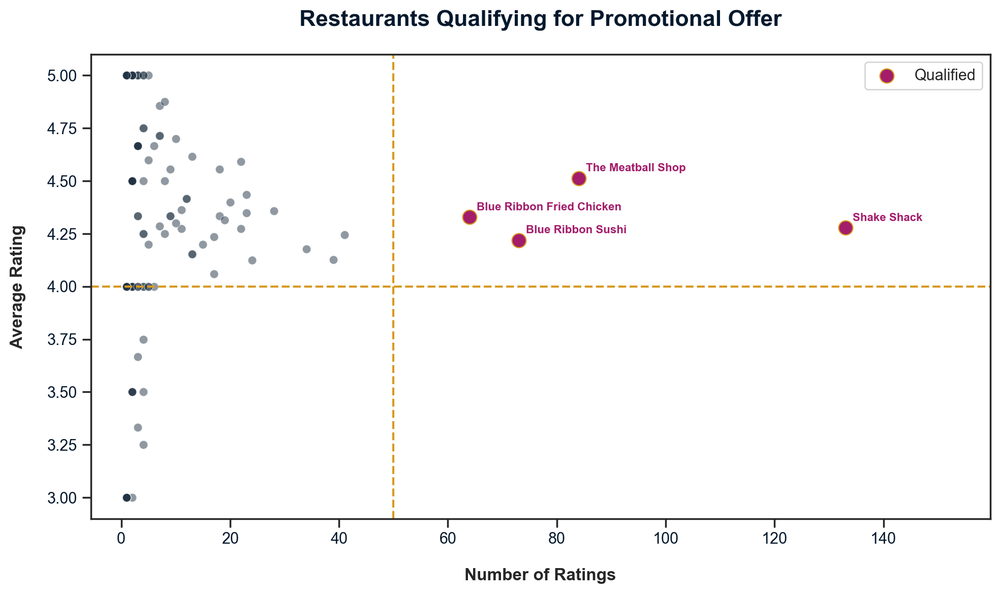

In [50]:
# Creates a clean copy of rated orders and ensures rating is numeric for aggregation
promo_data = data[data['rating'] != 0].copy()
promo_data['rating'] = pd.to_numeric(promo_data['rating'], errors='coerce')

# Calculates the count and average rating per restaurant from rated orders only
promo_data = promo_data.groupby('restaurant_name')['rating'].agg(['count', 'mean']).reset_index()

# Filters restaurants meeting both promotional criteria: 50+ ratings AND average rating above 4
qualified_restaurants = promo_data[(promo_data['count'] > 50) & (promo_data['mean'] > 4)]

# Sets the figure size for the promotional results
plt.figure(figsize=(10, 6))

# Plots all restaurants as muted background points for context
sns.scatterplot(data=promo_data, x='count', y='mean', color='#223444', alpha=0.5)

# Highlights qualifying restaurants with Berry color and Gold edge for visual distinction
sns.scatterplot(data=qualified_restaurants, x='count', y='mean', color=HPRIMARY, s=100, edgecolor=ACCENT, label='Qualified')

# Annotates each qualifying restaurant directly on the plot for immediate identification
for _, row in qualified_restaurants.iterrows():
    plt.annotate(row['restaurant_name'],
                 (row['count'], row['mean']),
                 textcoords='offset points',
                 xytext=(5, 5),
                 fontsize=8,
                 fontweight='bold',
                 color=HPRIMARY)

# Adds gold dashed reference lines to visually communicate the promotional thresholds
plt.axvline(50, color=ACCENT, linestyle='--', linewidth=1.5)
plt.axhline(4, color=ACCENT, linestyle='--', linewidth=1.5)

# Writes bold titles and refined axis labels with padding
plt.title('Restaurants Qualifying for Promotional Offer', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Ratings', fontsize=12, fontweight='bold', labelpad=15)
plt.ylabel('Average Rating', fontsize=12, fontweight='bold', labelpad=15)

# Extends the right x-axis boundary to prevent annotation clipping
plt.xlim(right=plt.xlim()[1] + 20)
plt.tight_layout()
plt.show()

# Extracts the list of qualifying restaurant names for the summary output
names = ", ".join(qualified_restaurants['restaurant_name'].tolist())

# Displays the qualifying restaurants with Berry styling for presentation clarity
display(HTML(f"""<div style="font-size:14px;">The restaurants qualifying for the promotion are:<br> <span style="color:#A31D6B; font-weight:bold;">{names}</span></div>"""))

#### **Question 13: Observations**
* **Promotional Eligibility:** Out of the hundreds of restaurants on the platform, only **4 restaurants** met the strict criteria for the promotional offer: **Shake Shack**, **The Meatball Shop**, **Blue Ribbon Sushi**, and **Blue Ribbon Fried Chicken**.
* **The "Gold Standard":** These restaurants represent the elite tier of FoodHub's ecosystem, successfully balancing high order volume with premium pricing and exceptional customer satisfaction.
* **Incentive Structure:** By limiting the promo to this top tier, FoodHub creates a clear aspirational goal for other restaurants. Qualifying for this **promotional offer** provides these top-performers with even more visibility, likely further increasing their dominance in the American and Japanese cuisine segments. Personalized outreach to these four restaurants to maximize partnership value would be a logical next step.

### **Question 14:** 
The company charges the restaurant 25`%` on the orders having cost greater than `$`20.00 USD, and 15`%` on the orders having cost greater than `$`5.00 USD. Find the net revenue generated by the company across all orders. 
[3 marks]

In [52]:
# Write the code here
# Defines the revenue calculation rules (25% for >$20, 15% for >$5)
def get_revenue(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0

# Creates a revenue column and calculates the total sum
data['revenue'] = data['cost_of_the_order'].apply(get_revenue)
net_revenue = data['revenue'].sum()

# Calculates the revenue contribution from high-value orders (cost > $20)
pct_high_value_revenue = data[data['cost_of_the_order'] > 20]['revenue'].sum() / net_revenue * 100

# Displays net revenue and high-value order contribution with Berry styling
display(HTML(
    f'Total Net Revenue generated by FoodHub: <span style="color:#A31D6B; font-weight:bold;">${net_revenue:,.2f}</span><br>'
    f'Revenue contribution from orders over <b>$20</b>: <span style="color:#A31D6B; font-weight:bold;">{pct_high_value_revenue:.1f}%</span>'
))

#### **Question 14: Observations**
* **Revenue Generation:** The total net revenue generated by the platform is **$6,166.30**.
* **High-Value Contribution:** Orders exceeding **$20** account for only **29.24%** of total orders but drive **59.8%** of total platform revenue, confirming their outsized contribution due to the higher **25%** commission rate.
* **Profitability Structure:** The tiered commission model effectively balances high-volume, low-cost orders with high-margin, premium orders, ensuring a steady revenue stream across different restaurant types.

### **Question 15:** 
The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

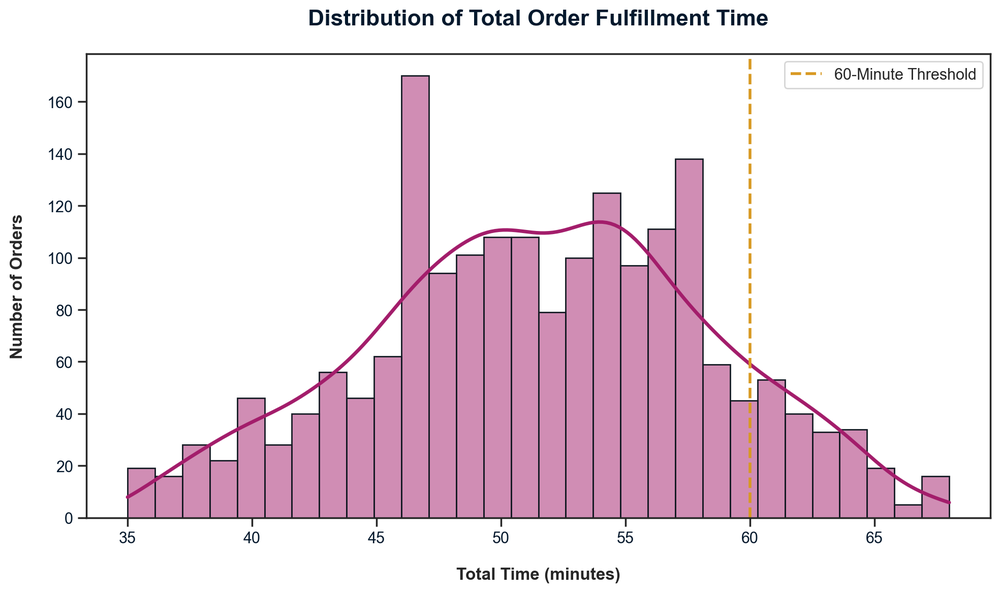

               Restaurant  Long Orders
              Shake Shack           26
        Blue Ribbon Sushi           19
        The Meatball Shop           13
         RedFarm Broadway            8
Blue Ribbon Fried Chicken            6


In [54]:
# Calculates total time by combining food prep and delivery time
data['total_time'] = data['food_preparation_time'] + data['delivery_time']

# Filters orders that exceed the 60-minute threshold
long_orders = data[data['total_time'] > 60]

# Calculates the percentage of orders over 60 minutes
percentage_long = (len(long_orders) / len(data)) * 100

# Identifies the restaurants most frequently associated with long orders
worst_offenders = long_orders['restaurant_name'].value_counts().head(5).reset_index()
worst_offenders.columns = ['Restaurant', 'Long Orders']

# Sets the figure size for the total time distribution chart
plt.figure(figsize=(10, 6))

# Displays histogram of total fulfillment time with 60-minute threshold line
sns.histplot(data['total_time'], bins=30, color=HPRIMARY,
             edgecolor='#141B24', kde=True,
             line_kws={'color': ACCENT, 'linewidth': 2.5})
plt.axvline(60, color=ACCENT, linestyle='--', linewidth=2, label='60-Minute Threshold')
plt.legend(fontsize=11)

# Writes bold titles and axis labels
plt.title('Distribution of Total Order Fulfillment Time', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Time (minutes)', fontsize=12, fontweight='bold', labelpad=15)
plt.ylabel('Number of Orders', fontsize=12, fontweight='bold', labelpad=15)
plt.tight_layout()
plt.show()

# Displays the percentage of long orders with Berry styling
display(HTML(f'Percentage of orders taking more than 60 minutes: <span style="color:#A31D6B; font-weight:bold;">{percentage_long:.2f}%</span>'))

# Displays the top 5 restaurants with the most long orders
display(HTML('<div style="font-size:14px;"><span style="color:#A31D6B; font-weight:bold;">Top 5 restaurants with most orders exceeding 60 minutes:</span></div>'))
print(worst_offenders.to_string(index=False))

#### **Question 15: Observations**
* **Service Efficiency:** Only **10.54%** of total orders exceed the **60-minute** threshold for total fulfillment (preparation + delivery), as shown by the distribution histogram with the threshold line.
* **Operational Stability:** Since the vast majority of orders (**89.46%**) are completed within an hour, the platform demonstrates strong logistical health and predictable service windows.
* **Long Order Concentration:** The top 5 restaurants associated with long orders are **Shake Shack** (26), **Blue Ribbon Sushi** (19), **The Meatball Shop** (13), **RedFarm Broadway** (8), and **Blue Ribbon Fried Chicken** (6). Notably these are also the platform's highest volume restaurants, meaning their appearance here reflects order volume exposure rather than necessarily poor service performance. A rate-based analysis (long orders as a percentage of each restaurant's total orders) would provide a fairer comparison.
* **Customer Experience:** These slow orders represent the highest risk segment for customer churn and warrant targeted operational review.

### **Question 16:** 
The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

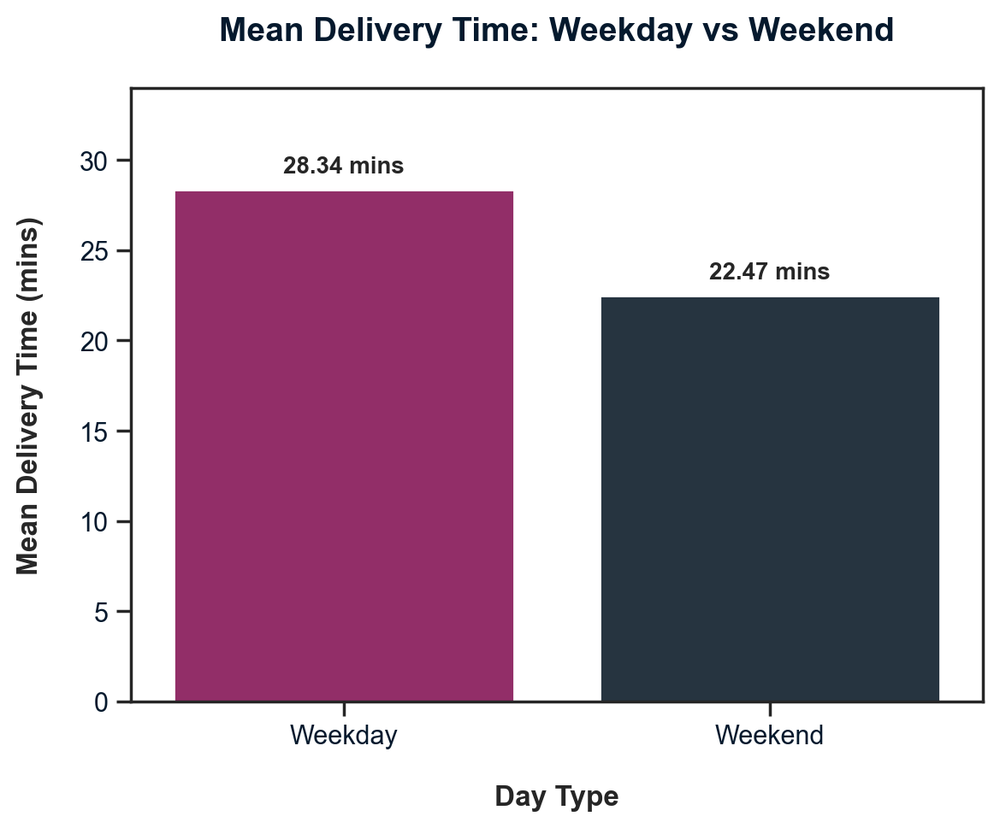

In [55]:
# Calculates the mean delivery time for each day type
day_delivery_means = data.groupby('day_of_the_week')['delivery_time'].mean()

# Sets the figure size for the delivery time comparison
plt.figure(figsize=(6, 5))

# Displays a bar chart comparing mean delivery times by day type
ax = sns.barplot(x=day_delivery_means.index, y=day_delivery_means.values,
                 hue=day_delivery_means.index, palette=C2PALETTE, legend=False)

# Annotates each bar with the mean delivery time value
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f} mins',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

# Writes bold titles and axis labels with extra padding
plt.title('Mean Delivery Time: Weekday vs Weekend', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Day Type', fontsize=12, fontweight='bold', labelpad=15)
plt.ylabel('Mean Delivery Time (mins)', fontsize=12, fontweight='bold', labelpad=15)
plt.margins(y=0.2)
plt.tight_layout()
plt.show()

# Identifies specific mean values for Weekdays and Weekends
weekday_avg = day_delivery_means['Weekday']
weekend_avg = day_delivery_means['Weekend']

# Runs a Welch t-test to assess statistical significance of the delivery time difference
from scipy.stats import ttest_ind
weekday_times = data[data['day_of_the_week'] == 'Weekday']['delivery_time']
weekend_times = data[data['day_of_the_week'] == 'Weekend']['delivery_time']
t_stat, p_value = ttest_ind(weekday_times, weekend_times, equal_var=False)

# Displays mean delivery times and statistical test results with Berry styling
display(HTML(
    f'The mean delivery time on <span style="color:#A31D6B; font-weight:bold;">Weekdays</span> is <span style="color:#A31D6B; font-weight:bold;">{weekday_avg:.2f} minutes</span><br>'
    f'The mean delivery time on <span style="color:#A31D6B; font-weight:bold;">Weekends</span> is <span style="color:#A31D6B; font-weight:bold;">{weekend_avg:.2f} minutes</span><br>'
    f'T-statistic: <span style="color:#A31D6B; font-weight:bold;">{t_stat:.2f}</span> | p-value: <span style="color:#A31D6B; font-weight:bold;">{p_value:.4f}</span>'
))

#### **Question 16: Observations**
* **Weekday Delays:** The mean delivery time on **Weekdays** is significantly higher at **28.34 minutes**. This likely reflects heavier traffic congestion and potentially lower courier availability during standard working hours.
* **Weekend Efficiency:** On **Weekends**, the mean delivery time drops to **22.47 minutes**. Despite higher order volume on weekends, faster delivery speed suggests reduced commercial traffic or better courier density compensates for the surge in demand.
* **Statistical Confirmation:** A Welch t-test confirms the **5.87-minute difference** is highly statistically significant (**t = 33.26, p < 0.0001**), meaning this gap is not due to random variation and can be relied upon to inform operational decisions.
* **Business Insight:** FoodHub could use this data to set dynamic estimated delivery times in the app, managing customer expectations more accurately on weekdays and reducing dissatisfaction from unmet delivery windows.

# Conclusion and Business Recommendations

### **Question 17:** 
What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

## **Conclusions**

The FoodHub dataset reveals a platform with strong operational fundamentals but clear opportunities to improve customer engagement and revenue optimization.

* FoodHub demonstrates **reliable service consistency**, with food preparation times ranging from 20 to 35 minutes (mean: 27 mins) and delivery times ranging from 15 to 33 minutes (mean: 24 mins). Combined, the average end-to-end order time sits at approximately 51 minutes, meeting customer expectations.
* **38.8% of orders carry no rating**, representing a significant blind spot in customer satisfaction data. A sub-group bias audit confirmed that unrated orders show no meaningful difference in prep or delivery time compared to rated orders, indicating the gap is driven by engagement inertia rather than poor service.
* **American and Japanese cuisines dominate** order volume, representing **30.8%** and **24.8%** of total orders respectively. The **Blue Ribbon** brand further reinforces Japanese cuisine dominance, appearing twice in the top 5 restaurants as Blue Ribbon Sushi and Blue Ribbon Fried Chicken, collectively accounting for **11.3%** of total platform volume. Lower volume cuisines such as Korean, French, Spanish, and Vietnamese represent underutilized segments.
* **Logistical Variance:** Mean delivery times differ significantly by day type; **Weekdays are approximately 5.87 minutes slower** than weekends (28.34 min vs 22.47 min). This difference is statistically confirmed (**t = 33.26, p < 0.0001**), meaning it reflects a real operational pattern rather than random variation.
* Orders rated **5.0 trend toward faster delivery times**, suggesting a measurable relationship between last-mile speed and customer satisfaction even where overall correlation between variables is weak.
* A subset of orders (**10.54%**) exceed the 60-minute total delivery threshold, representing a friction point that risks customer dissatisfaction and churn.

## **Business Recommendations**

1. **Close the feedback gap** by launching an automated post-delivery rating prompt within the app. With 736 unrated orders representing **38.8%** of the dataset, even a modest improvement in rating capture would significantly enrich the platform’s satisfaction data and improve restaurant accountability.
2. **Dynamic delivery communication:** Use the insights from the weekday/weekend delivery variance to set accurate, adjustable delivery time estimates in the app. Aligning customer expectations with the **~6-minute weekday delay** will proactively reduce dissatisfaction.
3. **Protect the 60-minute threshold** by targeting the restaurants most frequently associated with long wait times — particularly **Shake Shack** (26), **Blue Ribbon Sushi** (19), and **The Meatball Shop** (13). Note that their high volume partially explains their appearance here, so a rate-based review is recommended before applying penalties. Implementing service level alerts or dynamic prep time estimates for high-risk orders will allow FoodHub to manage the customer experience better.
4. **Activate the promotional criteria** defined in Question 13 to reward high-performing restaurants (e.g., Shake Shack, Blue Ribbon Sushi). This creates a "gold standard" benchmark that motivates other restaurants to improve their volume and rating averages.
5. **Build a loyalty program** centered on the top 5 most frequent customers (e.g., **ID 52832**). This high-value segment is a proven base for recurring revenue; a structured rewards tier would incentivize similar repeat behavior across the broader user base.
6. **Diversify cuisine demand** through targeted promotions for underperforming categories like Korean, French, Spanish, and Vietnamese. This reduces platform concentration risk and expands the active restaurant ecosystem beyond the dominant American and Japanese categories.

---
**Analytical Notes:** This analysis is limited by the absence of any time-based granularity beyond the weekday/weekend binary classification. Even a basic order date or time-of-day field would have enabled trend analysis, seasonality detection, and peak hour operational insights. Additional limitations include the lack of customer demographic data and direct qualitative feedback text. Future analysis could benefit from richer temporal data, NLP sentiment analysis on customer reviews, and predictive delivery time modeling by restaurant and day type.